In [7]:
!pip install gensim

In [8]:
from gensim.models import Word2Vec
sentences=[
    ['the','king','rules','the','kingdom'],
    ['the','queen','rules','the','kingdom'],
    ['the','prince','rules','the','kingdom'],
    ['an','apple','is','a','tasty','fruit'],
    ['a','banana','is','a','tasty','fruit'],
    ['an','orange','is','a','tasty','fruit'],
]
print("---Training Word2Vec Model---")
model_cbow = Word2Vec (sentences,vector_size=10,window=2,min_count=1,sg=0,epochs=100)
print("CBOW model trained sucessfully")
model_skipgram = Word2Vec (sentences,vector_size=10,window=2,min_count=1,sg=0,epochs=100)
print("Skipgram model trained sucessfully\n")
def test_similarities(model,model_name):
  print(f"---Semantic Similarities using {model_name} ---")
  sim_royal=model.wv.similarity('queen', 'king')
  print(f"Similarity ('queen', 'king'): {sim_royal:.4f}")
  sim_fruit=model.wv.similarity('apple', 'is')
  print(f"Similarity ('apple', 'mango'): {sim_fruit:.4f}")
  sim_unrelated=model.wv.similarity('queen', 'apple')
  print(f"Similarity ('queen', 'apple'): {sim_unrelated:.4f}")
test_similarities(model_cbow,"CBOW")
test_similarities(model_skipgram,"Skipgram")

---Training Word2Vec Model---
CBOW model trained sucessfully
Skipgram model trained sucessfully

---Semantic Similarities using CBOW ---
Similarity ('queen', 'king'): 0.4375
Similarity ('apple', 'mango'): 0.0369
Similarity ('queen', 'apple'): -0.0970
---Semantic Similarities using Skipgram ---
Similarity ('queen', 'king'): 0.4375
Similarity ('apple', 'mango'): 0.0369
Similarity ('queen', 'apple'): -0.0970


In [9]:
!pip install gensim --quiet
import gensim
from gensim.models import KeyedVectors
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
print ("Gensim version : ", gensim.__version__)

Gensim version :  4.4.0


In [11]:
import gensim.downloader as api
model = api.load("word2vec-google-news-300")
print(model.most_similar("google"))

[('google.com', 0.6711485981941223), ('google_yahoo', 0.6488178968429565), ('wikipedia', 0.643608033657074), ('www.google.com', 0.6258559226989746), ('googled', 0.6166064143180847), ('googling', 0.6086059212684631), ('slashdot', 0.5964587330818176), ('lifehacker', 0.5948858857154846), ('gizmodo', 0.5884420275688171), ('inurl', 0.5882638692855835)]


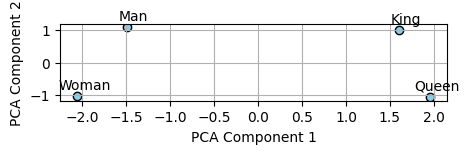

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Select a few words to visualize
words_to_visualize = [
    'King', 'Queen', 'Man', 'Woman'
]

# Filter out words not in the model's vocabulary
filtered_words = [word for word in words_to_visualize if word in model.key_to_index]

# Get the vectors for the filtered words
vectors = [model[word] for word in filtered_words]

# Apply PCA to reduce dimensions to 2
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

# Create a scatter plot
plt.figure(figsize=(5, 1))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], edgecolors='k', c='skyblue')

for i, word in enumerate(filtered_words):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]), textcoords="offset points", xytext=(5,5), ha='center')

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.show()


In [13]:
# Perform vector arithmetic: king - man + woman
# This operation is expected to result in a vector close to 'queen'.
result_vector = model['king'] - model['man'] + model['woman']

# Find the words most similar to the result vector
print("Words most similar to 'king' - 'man' + 'woman':")
similar_words = model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)

for word, similarity in similar_words:
    print(f"{word}: {similarity:.4f}")

Words most similar to 'king' - 'man' + 'woman':
queen: 0.7118
monarch: 0.6190
princess: 0.5902
crown_prince: 0.5499
prince: 0.5377


In [14]:
import plotly.express as px
import pandas as pd

# Create data_for_plotly using the filtered_words and vectors_2d from the PCA visualization
data_for_plotly = pd.DataFrame({
    'word': filtered_words,
    'x': vectors_2d[:, 0],
    'y': vectors_2d[:, 1]
})

# Get the list of words from the DataFrame used for PCA visualization
words = data_for_plotly['word'].tolist()

# Initialize an empty similarity matrix
similarity_matrix = pd.DataFrame(index=words, columns=words)

# Populate the similarity matrix
for i in range(len(words)):
    for j in range(len(words)):
        word1 = words[i]
        word2 = words[j]
        # model.similarity() calculates cosine similarity
        similarity_matrix.loc[word1, word2] = model.similarity(word1, word2)

# Convert the matrix to float type for the heatmap
similarity_matrix = similarity_matrix.astype(float)

# Create an interactive heatmap using Plotly Express
fig = px.imshow(
    similarity_matrix,
    text_auto=True, # Show similarity values on the heatmap cells
    aspect="auto",
    title='Cosine Similarity Heatmap for Word Embeddings',
    labels=dict(x="Word 2", y="Word 1", color="Similarity"),
    color_continuous_scale=px.colors.sequential.Viridis # Choose a color scale
)

# Update layout for better readability, especially for small matrices
fig.update_xaxes(side="top")
fig.update_layout(xaxis_nticks=len(words), yaxis_nticks=len(words))

fig.show()